# M³TrustEval-XQuAD  
## Modular Multilingual Trustworthiness Evaluation of a HuggingFace LLM

### Course Project: Large Language Models

---

## 1. Project Summary

In this project, you will evaluate a single HuggingFace instruction-tuned language model on a real multilingual question-answering dataset.

The project focuses on five advanced LLM topics:

1. **Evaluation**
2. **Interpretability**
3. **Bias / Ethics**
4. **Modularity**
5. **Multilinguality**

The key idea is that LLM evaluation should not be limited to exact answer accuracy.  
A trustworthy evaluation should also ask:

- Does the model answer correctly?
- Is the explanation grounded in the given context?
- Does a modular verifier improve the answer?
- Does the model perform equally well across languages?
- Are there language-based performance disparities that raise fairness and ethical concerns?

---

## 2. Dataset and Model

### Dataset

We use **XQuAD** from HuggingFace:

- Dataset: `google/xquad`
- Task: Cross-lingual extractive question answering
- Languages used in this notebook: English, Arabic, German, Spanish, Turkish

XQuAD is useful here because the same QA examples are translated across multiple languages.  
This allows us to compare the same model across languages in a controlled way.

### Model

We use exactly one HuggingFace model:

- Model: `Qwen/Qwen2.5-0.5B-Instruct`

This is intentionally a small model so that the notebook can run on limited GPU resources.


# 3. Reference Papers and Links

This project is inspired by the following papers and resources.

## Main Evaluation Reference

**HELM: Holistic Evaluation of Language Models**  
Link: https://arxiv.org/abs/2211.09110

HELM motivates the idea that language models should be evaluated across multiple metrics, not just accuracy.

## Trustworthiness Reference

**DecodingTrust: A Comprehensive Assessment of Trustworthiness in GPT Models**  
Link: https://arxiv.org/abs/2306.11698

DecodingTrust motivates the trustworthiness perspective, including fairness, robustness, ethics, privacy, and bias.

## Modularity / Self-Consistency Reference

**SelfCheckGPT: Zero-Resource Black-Box Hallucination Detection for Generative LLMs**  
Link: https://arxiv.org/abs/2303.08896

SelfCheckGPT motivates checking model outputs through consistency and verification.

## Dataset Reference

**XQuAD: Cross-lingual Question Answering Dataset**  
HuggingFace: https://huggingface.co/datasets/google/xquad  
GitHub: https://github.com/google-deepmind/xquad

## Model Reference

**Qwen2.5-0.5B-Instruct**  
HuggingFace: https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct


# 4. Formal Project Statement

## Goal

Build a multilingual and modular evaluation framework for a HuggingFace LLM using the XQuAD dataset.

## Required Tasks

Students must:

1. Load the XQuAD dataset from HuggingFace.
2. Select a small multilingual subset from multiple languages.
3. Load one HuggingFace instruction-tuned model.
4. Run a **direct answering baseline**.
5. Run a **modular pipeline** consisting of:
   - generator
   - verifier
   - reviser
6. Compute answer quality metrics:
   - Exact Match
   - Token-level F1
7. Compute interpretability / faithfulness metrics:
   - whether the evidence appears in the context
   - whether the explanation is grounded in the context
8. Compute multilingual fairness metrics:
   - per-language performance
   - English vs. non-English gap
   - worst-language performance
   - language performance disparity
9. Compare the direct and modular systems.
10. Write a short discussion about bias, ethics, limitations, and possible improvements.

## Final Deliverables

Students should submit:

- completed notebook,
- generated CSV files,
- plots,
- final written analysis.

## Important Rule

Use only one LLM for generation and verification:

`Qwen/Qwen2.5-0.5B-Instruct`


# 5. Expected Research Questions

Your final report should answer:

1. Does the modular pipeline improve performance over the direct baseline?
2. Does the verifier improve explanation faithfulness?
3. Which language has the lowest performance?
4. Is there a large performance gap between English and non-English languages?
5. Can cross-lingual performance disparity be considered a form of language bias?
6. What are the ethical implications of deploying a model that performs much better in some languages than others?
7. What are the limitations of using the same model as both generator and verifier?
8. How could this project be extended to become a stronger research study?


# 6. Install Required Libraries

Run this cell in Colab, Kaggle, or a fresh local environment.

Recommended runtime:

- GPU enabled
- Internet enabled


In [ ]:
!pip -q install datasets transformers accelerate torch pandas numpy matplotlib tqdm rapidfuzz tabulate


# 7. Imports and Configuration

This notebook intentionally uses only one HuggingFace LLM.

You may reduce `N_EXAMPLES_PER_LANGUAGE` for quick debugging.  
For the final run, use a larger number if your GPU allows it.


In [ ]:
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
DATASET_ID = "google/xquad"

LANG_CONFIGS = {
    "en": "English",
    "ar": "Arabic",
    "de": "German",
    "es": "Spanish",
    "tr": "Turkish"
}

N_EXAMPLES_PER_LANGUAGE = 150

MAX_CONTEXT_CHARS = 1500
MAX_NEW_TOKENS = 128

# 8. Load the XQuAD Dataset

We load the same dataset in several languages.  
Then we keep examples that have matching IDs across languages, so that the same underlying QA item can be compared cross-lingually.


In [ ]:
datasets_per_lang = {}

for lang_code, lang_name in LANG_CONFIGS.items():
    ds = load_dataset(DATASET_ID, f"xquad.{lang_code}", split="validation")
    datasets_per_lang[lang_code] = ds

id_map = {}

for lang_code, ds in datasets_per_lang.items():
    for ex in ds:
        ex_id = ex["id"]

        if ex_id not in id_map:
            id_map[ex_id] = {}

        answers = ex["answers"]["text"]
        gold = answers[0] if len(answers) > 0 else ""

        id_map[ex_id][lang_code] = {
            "id": ex_id,
            "lang": lang_code,
            "title": "",
            "context": ex["context"],
            "question": ex["question"],
            "gold_answer": gold
        }

required_langs = set(LANG_CONFIGS.keys())
filtered_rows = []

for ex_id, lang_dict in id_map.items():
    if required_langs.issubset(lang_dict.keys()):
        for lang_code in required_langs:
            filtered_rows.append(lang_dict[lang_code])

df = pd.DataFrame(filtered_rows)

df = (
    df.groupby("lang", group_keys=False)
      .head(N_EXAMPLES_PER_LANGUAGE)
      .reset_index(drop=True)
)

df

,id,lang,title,context,question,gold_answer
0,56beb4343aeaaa14008c925b,tr,,﻿Panthers savunması ligdeki derecesi altıncı s...,Panthers savunması kaç sayı bırakmıştır?,308
1,56beb4343aeaaa14008c925b,es,,"﻿Los Panthers, que además de liderar las inter...",¿Cuántos puntos dejaron escapar en defensa los...,308
2,56beb4343aeaaa14008c925b,ar,,لم يتخلى فريق بانثرز سوى عن 308 نقطة، ليحتل ال...,كم نقطة تخلى عنها دفاع البانثرز؟,308
3,56beb4343aeaaa14008c925b,en,,"The Panthers defense gave up just 308 points, ...",How many points did the Panthers defense surre...,308
4,56beb4343aeaaa14008c925b,de,,Die Verteidigung der Panthers gab nur 308 Punk...,Wie viele Punkte gab die Verteidigung der Pant...,308
...,...,...,...,...,...,...
745,56e1ee4de3433e1400423210,tr,,Bilinen birçok karmaşıklık sınıfının eşit olma...,Genellikle karmaşıklık sınıflarının değerine a...,eşit olmadığından şüphelenilmektedir
746,56e1ee4de3433e1400423210,es,,"Se sospecha, aunque no ha sido demostrado, que...",¿Cuál es el supuesto no demostrado generalment...,desiguales
747,56e1ee4de3433e1400423210,ar,,العديد من أصناف التعقيد المعروفة يشتبه في أنها...,ما هو الافتراض غير المثبت الذي يُعزى عموماً إل...,يشتبه في أنها غير متساوية
748,56e1ee4de3433e1400423210,en,,Many known complexity classes are suspected to...,What is the unproven assumption generally ascr...,suspected to be unequal


# 9. Load the HuggingFace Model

This notebook uses only one model:

`Qwen/Qwen2.5-0.5B-Instruct`

The same model is used for:

- direct answering,
- answer generation,
- verification,
- revision.

This makes the project simple and reproducible, but it also creates an important limitation: the verifier may share the same weaknesses as the generator.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,
    device_map="auto"
)

model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

# 10. Helper Functions for Text Normalization and JSON Parsing

The model is asked to return JSON, but small LLMs may not always produce perfect JSON.  
The functions below make the evaluation more robust.


In [ ]:
import json
import re
import string
from collections import Counter
from rapidfuzz import fuzz


def extract_json(text):
    """
    Extract the first JSON object from model output.
    Returns {} if parsing fails.
    """
    if not text:
        return {}

    text = text.strip()
    text = re.sub(r"^```(?:json)?", "", text)
    text = re.sub(r"```$", "", text).strip()

    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        return {}

    candidate = match.group(0)

    try:
        return json.loads(candidate)
    except Exception:
        return {}


def normalize_answer(text):
    """
    Lowercase, remove punctuation, and collapse whitespace.
    """
    if text is None:
        return ""

    text = str(text).lower()

    translator = str.maketrans("", "", string.punctuation)
    text = text.translate(translator)

    text = " ".join(text.split())
    return text


def token_f1(prediction, ground_truth):
    """
    Token-level F1 score.
    """
    pred_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(ground_truth).split()

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0
    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)

    return 2 * precision * recall / (precision + recall)


def exact_match(prediction, ground_truth):
    """
    Exact match after normalization.
    """
    return int(
        normalize_answer(prediction) ==
        normalize_answer(ground_truth)
    )


def fuzzy_match(prediction, ground_truth):
    """
    Fuzzy string similarity score (0-100).
    """
    pred = normalize_answer(prediction)
    gold = normalize_answer(ground_truth)

    if not pred and not gold:
        return 100
    if not pred or not gold:
        return 0

    return fuzz.ratio(pred, gold)

# 11. Model Generation Function

This function sends a prompt to the model and returns the generated text.

The function uses the model's chat template when available.


In [177]:
@torch.inference_mode()
def generate_text(prompt, max_new_tokens=MAX_NEW_TOKENS):
    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    generated_text = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return generated_text.strip()

# 12. Direct Answering Prompt

The direct baseline asks the model to answer using only the context.

The output must contain:

- `answer`
- `explanation`
- `evidence`
- `confidence`


In [178]:
def build_direct_prompt(context, question):
    context = context[:MAX_CONTEXT_CHARS]

    prompt = f"""
You are an extractive question answering assistant.

Your task is to answer the question using ONLY the provided context.
Do not use outside knowledge.
If the answer cannot be found in the context, return "Not found".

Return ONLY a valid JSON object.

Context:
{context}

Question:
{question}

Definitions:
- answer: the shortest exact phrase from the context that answers the question.
- explanation: one concise sentence explaining why the answer is correct using only information from the context.
- evidence: the exact sentence from the context that directly supports the answer.
- confidence: a float number between 0.0 and 1.0 indicating how confident you are that the answer is correct based only on the context.

Rules:
- Output valid JSON only.
- Do not include Markdown or code fences.
- Do not include any text before or after the JSON.
- Do not invent information.
- Copy the answer and evidence exactly from the context whenever possible.

JSON format:
{{
  "answer": "<shortest exact phrase from the context>",
  "explanation": "<one concise sentence based only on the context>",
  "evidence": "<exact supporting sentence from the context>",
  "confidence": <float number between 0 and 1>
}}
"""
    return prompt.strip()


def run_direct(context, question):
    prompt = build_direct_prompt(context, question)

    raw_output = generate_text(prompt)

    result = extract_json(raw_output)

    return {
        "answer": result.get("answer", ""),
        "explanation": result.get("explanation", ""),
        "evidence": result.get("evidence", ""),
        "confidence": result.get("confidence", "")
    }

# 13. Run the Direct Baseline

This cell may take time depending on the number of examples and your hardware.


In [ ]:
direct_results = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Direct Baseline"):
    result = run_direct(
        context=row["context"],
        question=row["question"]
    )

    direct_results.append({
        "id": row["id"],
        "lang": row["lang"],
        "question": row["question"],
        "gold_answer": row["gold_answer"],
        "pred_answer": result["answer"],
        "explanation": result["explanation"],
        "evidence": result["evidence"],
        "confidence": result["confidence"]
    })

direct_df = pd.DataFrame(direct_results)

print(f"Completed {len(direct_df)} examples.")
direct_df.head()

Direct Baseline: 100%|██████████| 750/750 [47:38<00:00,  3.81s/it]

Completed 750 examples.


,id,lang,question,gold_answer,pred_answer,explanation,evidence,confidence
0,56beb4343aeaaa14008c925b,tr,Panthers savunması kaç sayı bırakmıştır?,308,308,The context states that Panther's savunması li...,Panthers savunması liginde 308 sayı bıraktı.,1.0
1,56beb4343aeaaa14008c925b,es,¿Cuántos puntos dejaron escapar en defensa los...,308,308,The context states that Los Panthers led the N...,The context provides specific numbers about th...,1.0
2,56beb4343aeaaa14008c925b,ar,كم نقطة تخلى عنها دفاع البانثرز؟,308,308,The context states that 'فريق بانثرز' (Bengals...,النص يشير إلى أن الفريق بانثرز لم يخلى عنه إلا...,1.0
3,56beb4343aeaaa14008c925b,en,How many points did the Panthers defense surre...,308,308,The context states that the Panthers defense g...,The context provides this specific information...,1.0
4,56beb4343aeaaa14008c925b,de,Wie viele Punkte gab die Verteidigung der Pant...,308,308,The context states that 'Die Verteidigung der ...,Die Verteidigung der Panthers gab nur 308 Punk...,1.0


# 14. Modular Pipeline Prompt

The modular pipeline has three stages:

1. **Generator**: produces an initial answer.
2. **Verifier**: checks whether the answer is supported by the context.
3. **Reviser**: produces a corrected final answer if needed.

For simplicity, this notebook uses the same HuggingFace model for all stages.


In [ ]:
def build_verifier_prompt(context, question, answer):
    context = context[:MAX_CONTEXT_CHARS]

    prompt = f"""
You are a fact-checking verifier.

Your task is to determine whether the proposed answer is fully supported by the provided context.
Use ONLY the provided context.

Return ONLY a valid JSON object.

Context:
{context}

Question:
{question}

Proposed Answer:
{answer}

Definitions:
- supported: true if the proposed answer is directly supported by the context; otherwise false.
- explanation: one concise sentence explaining why the answer is supported or unsupported.
- evidence: the exact sentence from the context that best justifies your decision. If no supporting evidence exists, return an empty string.

Rules:
- Output valid JSON only.
- Do not include Markdown or code fences.
- Do not include any text before or after the JSON.
- Base your decision only on the provided context.
- Quote the evidence exactly from the context whenever possible.

JSON format:
{{
  "supported": true or false,
  "explanation": "<one concise sentence>",
  "evidence": "<exact supporting sentence or empty string>"
}}
"""
    return prompt.strip()


def build_reviser_prompt(context, question, answer, verification):
    context = context[:MAX_CONTEXT_CHARS]

    prompt = f"""
You are a question answering reviser.

Your task is to produce the best possible answer using ONLY the provided context.

The original answer may be incorrect, incomplete, or unsupported.
Use the verification result to improve the final answer when necessary.

Return ONLY a valid JSON object.

Context:
{context}

Question:
{question}

Original Answer:
{answer}

Verification Result:
{verification}

Definitions:
- answer: the shortest exact phrase from the context that correctly answers the question.
- explanation: one concise sentence explaining why the final answer is correct using only information from the context.
- evidence: the exact sentence from the context that directly supports the final answer.
- confidence: a number between 0.0 and 1.0 indicating how confident you are that the final answer is correct based only on the context.

Rules:
- Output valid JSON only.
- Do not include Markdown or code fences.
- Do not include any text before or after the JSON.
- Do not use outside knowledge.
- If the original answer is already correct and fully supported, keep it unchanged.
- If it is unsupported or incorrect, replace it with the correct answer from the context.
- If the answer cannot be found in the context, return "Not found".
- Copy the answer and evidence exactly from the context whenever possible.

JSON format:
{{
  "answer": "<shortest exact phrase from the context>",
  "explanation": "<one concise sentence based only on the context>",
  "evidence": "<exact supporting sentence from the context>",
  "confidence": <number between 0.0 and 1.0>
}}
"""
    return prompt.strip()    
    
def run_modular(context, question):
    generator_result = run_direct(context, question)

    initial_answer = generator_result["answer"]

    verifier_prompt = build_verifier_prompt(
        context,
        question,
        initial_answer
    )

    verifier_raw = generate_text(verifier_prompt)
    verifier_result = extract_json(verifier_raw)

    supported = verifier_result.get("supported", False)

    if isinstance(supported, str):
        supported = supported.lower() == "true"

    if not supported:
        reviser_prompt = build_reviser_prompt(
            context,
            question,
            initial_answer,
            verifier_result
        )

        reviser_raw = generate_text(reviser_prompt)
        revised_result = extract_json(reviser_raw)

        return {
            "answer": revised_result.get("answer", initial_answer),
            "explanation": revised_result.get("explanation", ""),
            "evidence": revised_result.get("evidence", ""),
            "confidence": revised_result.get("confidence", ""),
            "supported": supported
        }

    return {
        "answer": generator_result["answer"],
        "explanation": generator_result["explanation"],
        "evidence": generator_result["evidence"],
        "confidence": generator_result["confidence"],
        "supported": supported
    }

# 15. Run the Modular Pipeline


In [ ]:
modular_results = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Modular Pipeline"):
    result = run_modular(
        context=row["context"],
        question=row["question"]
    )

    modular_results.append({
        "id": row["id"],
        "lang": row["lang"],
        "question": row["question"],
        "gold_answer": row["gold_answer"],
        "pred_answer": result["answer"],
        "explanation": result["explanation"],
        "evidence": result["evidence"],
        "confidence": result["confidence"],
        "supported": result["supported"]
    })

modular_df = pd.DataFrame(modular_results)

print(f"Completed {len(modular_df)} examples.")
modular_df.head()

Modular Pipeline: 100%|██████████| 750/750 [1:19:29<00:00,  6.36s/it]

Completed 750 examples.


,id,lang,question,gold_answer,pred_answer,explanation,evidence,confidence,supported
0,56beb4343aeaaa14008c925b,tr,Panthers savunması kaç sayı bırakmıştır?,308,308,The context states that Panther's savunması li...,Panthers savunması liginde 308 sayı bıraktı.,1.0,True
1,56beb4343aeaaa14008c925b,es,¿Cuántos puntos dejaron escapar en defensa los...,308,308,The context states that Los Panthers led the N...,The context provides specific numbers about th...,1.0,True
2,56beb4343aeaaa14008c925b,ar,كم نقطة تخلى عنها دفاع البانثرز؟,308,308,The context states that 'فريق بانثرز' (Bengals...,النص يشير إلى أن الفريق بانثرز لم يخلى عنه إلا...,1.0,True
3,56beb4343aeaaa14008c925b,en,How many points did the Panthers defense surre...,308,308,The context states that the Panthers defense g...,The context provides this specific information...,1.0,True
4,56beb4343aeaaa14008c925b,de,Wie viele Punkte gab die Verteidigung der Pant...,308,308,The context states that 'Die Verteidigung der ...,Die Verteidigung der Panthers gab nur 308 Punk...,1.0,True


# 16. Compute Evaluation Metrics

We compute:

- Exact Match
- Token F1
- Fuzzy Match
- Evidence faithfulness
- Explanation faithfulness

The faithfulness metrics are simple approximations.  
They check whether the evidence and explanation are grounded in the context.


In [ ]:
def evidence_in_context(evidence, context, thresh=65):
  normalized_evidence = normalize_answer(evidence)
  normalized_context = normalize_answer(context)
  if (normalized_evidence == "") or (normalized_context == ""):
    return 0

  score = fuzz.partial_ratio(
        normalize_answer(evidence),
        normalize_answer(context),
    )

  if int(score) >= thresh:
    return 1

  return 0

def answer_in_explanation(answer, explanation):
  normalized_answer = normalize_answer(answer)
  normalized_explanation = normalize_answer(explanation)
  if (normalized_answer == "") or (normalized_explanation == ""):
    return 0

  if (normalized_answer in normalized_explanation):
    return 1
  else:
    return 0

def faithfulness(answer, explanation, evidence, context):
  evidence_score = evidence_in_context(evidence, context)
  explanation_score = answer_in_explanation(answer, explanation)

  return round((evidence_score + explanation_score) / 2, 3)


def evaluate_predictions(results_df, source_df):
    """
    Compute all evaluation metrics for a prediction DataFrame.
    """
    context_map = source_df.set_index(["id", "lang"])["context"].to_dict()

    df_eval = results_df.copy()

    em_scores = []
    f1_scores = []
    fuzzy_scores = []
    evidence_scores = []
    explanation_scores = []
    faithful_scores = []

    for _, row in df_eval.iterrows():
        context = context_map[(row["id"], row["lang"])]

        em_scores.append(
            exact_match(row["pred_answer"], row["gold_answer"])
        )

        f1_scores.append(
            token_f1(row["pred_answer"], row["gold_answer"])
        )

        fuzzy_scores.append(
            fuzzy_match(row["pred_answer"], row["gold_answer"])
        )

        evidence_scores.append(
            evidence_in_context(row["evidence"], context)
        )

        explanation_scores.append(
            answer_in_explanation(
                row["pred_answer"],
                row["explanation"]
            )
        )

        faithful_scores.append(
            faithfulness(
                row["pred_answer"],
                row["explanation"],
                row["evidence"],
                context
            )
        
        )

    df_eval["exact_match"] = em_scores
    df_eval["token_f1"] = f1_scores
    df_eval["fuzzy_match"] = fuzzy_scores
    df_eval["evidence_in_context"] = evidence_scores
    df_eval["answer_in_explanation"] = explanation_scores
    df_eval["faithfulness"] = faithful_scores

    return df_eval


direct_df = evaluate_predictions(direct_df, df)
modular_df = evaluate_predictions(modular_df, df)

direct_df.head()

,id,lang,question,gold_answer,pred_answer,explanation,evidence,confidence,exact_match,token_f1,fuzzy_match,evidence_in_context,answer_in_explanation,faithfulness
0,56beb4343aeaaa14008c925b,tr,Panthers savunması kaç sayı bırakmıştır?,308,308,The context states that Panther's savunması li...,Panthers savunması liginde 308 sayı bıraktı.,1.0,1,1.0,100.0,1,1,1.0
1,56beb4343aeaaa14008c925b,es,¿Cuántos puntos dejaron escapar en defensa los...,308,308,The context states that Los Panthers led the N...,The context provides specific numbers about th...,1.0,1,1.0,100.0,0,1,0.5
2,56beb4343aeaaa14008c925b,ar,كم نقطة تخلى عنها دفاع البانثرز؟,308,308,The context states that 'فريق بانثرز' (Bengals...,النص يشير إلى أن الفريق بانثرز لم يخلى عنه إلا...,1.0,1,1.0,100.0,1,1,1.0
3,56beb4343aeaaa14008c925b,en,How many points did the Panthers defense surre...,308,308,The context states that the Panthers defense g...,The context provides this specific information...,1.0,1,1.0,100.0,0,1,0.5
4,56beb4343aeaaa14008c925b,de,Wie viele Punkte gab die Verteidigung der Pant...,308,308,The context states that 'Die Verteidigung der ...,Die Verteidigung der Panthers gab nur 308 Punk...,1.0,1,1.0,100.0,1,1,1.0


# 17. Aggregate Results by Mode and Language

This table is the main evaluation output of the project.


In [ ]:
direct_results = direct_df.copy()
direct_results["mode"] = "Direct"

modular_results = modular_df.copy()
modular_results["mode"] = "Modular"

all_results = pd.concat(
    [direct_results, modular_results],
    ignore_index=True
)

summary_df = (
    all_results
    .groupby(["mode", "lang"])
    .agg(
        Exact_Match=("exact_match", "mean"),
        Token_F1=("token_f1", "mean"),
        Fuzzy_Match=("fuzzy_match", "mean"),
        Faithfulness=("faithfulness", "mean"),
        Evidence_Rate=("evidence_in_context", "mean")
    )
    .reset_index()
)

summary_df["Exact_Match"] *= 100
summary_df["Token_F1"] *= 100
summary_df["Faithfulness"] *= 100
summary_df["Evidence_Rate"] *= 100

summary_df = summary_df.round(2)

summary_df

,mode,lang,Exact_Match,Token_F1,Fuzzy_Match,Faithfulness,Evidence_Rate
0,Direct,ar,28.67,33.81,47.64,30.67,16.00
1,Direct,de,40.67,47.81,56.27,48.33,35.33
2,Direct,en,56.67,62.67,69.52,64.33,60.00
3,Direct,es,36.67,44.50,54.25,44.67,31.33
4,Direct,tr,22.67,30.54,38.02,32.00,24.00
5,Modular,ar,28.67,33.47,47.30,30.00,15.33
6,Modular,de,39.33,46.47,55.89,49.67,35.33
7,Modular,en,57.33,62.89,70.34,64.00,58.67
8,Modular,es,35.33,43.17,53.96,43.67,28.67
9,Modular,tr,23.33,32.43,40.20,32.00,22.67


# 18. Compare Direct vs. Modular Systems

This table shows whether the modular pipeline improved over the direct baseline.


In [ ]:
comparison_df = (
    all_results
    .groupby("mode")
    .agg(
        Exact_Match=("exact_match", "mean"),
        Token_F1=("token_f1", "mean"),
        Fuzzy_Match=("fuzzy_match", "mean"),
        Faithfulness=("faithfulness", "mean"),
        Evidence_Rate=("evidence_in_context", "mean")
    )
)

comparison_df["Exact_Match"] *= 100
comparison_df["Token_F1"] *= 100
comparison_df["Faithfulness"] *= 100
comparison_df["Evidence_Rate"] *= 100

comparison_df = comparison_df.round(2)

print("Overall Performance")
display(comparison_df)

improvement_df = (
    comparison_df.loc["Modular"] - comparison_df.loc["Direct"]
).to_frame(name="Modular - Direct")

print("\nImprovement (percentage points except Fuzzy Match)")
display(improvement_df.round(2))

Overall Performance


,Exact_Match,Token_F1,Fuzzy_Match,Faithfulness,Evidence_Rate
mode,,,,,
Direct,37.07,43.86,53.14,44.00,33.33
Modular,36.80,43.69,53.54,43.87,32.13



Improvement (percentage points except Fuzzy Match)


,Modular - Direct
Exact_Match,-0.27
Token_F1,-0.17
Fuzzy_Match,0.40
Faithfulness,-0.13
Evidence_Rate,-1.20


# 19. Multilingual Fairness and Language-Bias Metrics

In this project, **bias** is studied as language-based performance disparity.

If the model performs much better in English than in Arabic, Turkish, Spanish, or German, this may indicate a form of language bias or unequal service quality.

We compute:

- English vs. non-English performance gap
- best-language vs. worst-language gap
- standard deviation across languages
- worst-language performance


In [ ]:
def compute_language_fairness(results_df, metric="token_f1"):
    """
    Compute multilingual fairness statistics for a given metric.
    """

    lang_scores = results_df.groupby("lang")[metric].mean()

    english_score = lang_scores.get("en", np.nan)

    non_english = lang_scores.drop("en", errors="ignore")
    non_english_score = non_english.mean() if len(non_english) > 0 else np.nan

    fairness = {
        "English": english_score,
        "Non-English": non_english_score,
        "English_vs_NonEnglish_Gap": english_score - non_english_score,
        "Best_Language": lang_scores.idxmax(),
        "Best_Score": lang_scores.max(),
        "Worst_Language": lang_scores.idxmin(),
        "Worst_Score": lang_scores.min(),
        "Best_vs_Worst_Gap": lang_scores.max() - lang_scores.min(),
        "Std_Across_Languages": lang_scores.std()
    }

    return pd.DataFrame([fairness])


direct_fairness = compute_language_fairness(direct_df)
direct_fairness["mode"] = "Direct"

modular_fairness = compute_language_fairness(modular_df)
modular_fairness["mode"] = "Modular"

fairness_df = pd.concat(
    [direct_fairness, modular_fairness],
    ignore_index=True
)

score_columns = [
    "English",
    "Non-English",
    "English_vs_NonEnglish_Gap",
    "Best_Score",
    "Worst_Score",
    "Best_vs_Worst_Gap",
    "Std_Across_Languages"
]

fairness_df[score_columns] = (
    fairness_df[score_columns] * 100
).round(2)

fairness_df = fairness_df[
    [
        "mode",
        "English",
        "Non-English",
        "English_vs_NonEnglish_Gap",
        "Best_Language",
        "Best_Score",
        "Worst_Language",
        "Worst_Score",
        "Best_vs_Worst_Gap",
        "Std_Across_Languages"
    ]
]

fairness_df

,mode,English,Non-English,English_vs_NonEnglish_Gap,Best_Language,Best_Score,Worst_Language,Worst_Score,Best_vs_Worst_Gap,Std_Across_Languages
0,Direct,62.67,39.16,23.51,en,62.67,tr,30.54,32.13,12.73
1,Modular,62.89,38.89,24.01,en,62.89,tr,32.43,30.47,12.33


# 20. Cross-Lingual Consistency

Because XQuAD contains parallel examples, we can compare whether the model is correct or incorrect on the same question across different languages.

A simple consistency metric:

> For each question ID, calculate how consistent the model's correctness is across languages.

If a model answers the English version correctly but fails the Arabic or Turkish version, this indicates cross-lingual inconsistency.


In [ ]:
def compute_cross_lingual_consistency(results_df):
    """
    Compute cross-lingual consistency based on Exact Match correctness.

    Consistency for an ID:
        (#languages in the majority correctness class) / (#languages)

    1.0 -> all languages are either correct or incorrect.
    0.6 -> 3/5 languages agree.
    """

    df = results_df.copy()
    df["correct"] = df["exact_match"].astype(int)

    consistency_rows = []

    for qid, group in df.groupby("id"):
        correctness = group["correct"].tolist()

        majority = max(sum(correctness), len(correctness) - sum(correctness))
        consistency = majority / len(correctness)

        consistency_rows.append({
            "id": qid,
            "consistency": consistency,
            "n_languages": len(correctness)
        })

    consistency_df = pd.DataFrame(consistency_rows)

    summary = pd.DataFrame({
        "Average_Consistency": [consistency_df["consistency"].mean()],
        "Perfectly_Consistent": [(consistency_df["consistency"] == 1.0).mean()],
        "Average_Languages": [consistency_df["n_languages"].mean()]
    })

    summary[["Average_Consistency", "Perfectly_Consistent"]] *= 100
    summary = summary.round(2)

    return consistency_df, summary


direct_consistency, direct_consistency_summary = compute_cross_lingual_consistency(direct_df)
direct_consistency_summary["mode"] = "Direct"

modular_consistency, modular_consistency_summary = compute_cross_lingual_consistency(modular_df)
modular_consistency_summary["mode"] = "Modular"

consistency_summary = pd.concat(
    [direct_consistency_summary, modular_consistency_summary],
    ignore_index=True
)

consistency_summary = consistency_summary[
    [
        "mode",
        "Average_Consistency",
        "Perfectly_Consistent",
        "Average_Languages"
    ]
]

consistency_summary

,mode,Average_Consistency,Perfectly_Consistent,Average_Languages
0,Direct,78.67,30.00,5.0
1,Modular,77.87,28.67,5.0


# 21. Plot Results

Create simple plots for:

1. Token F1 by language and mode
2. Faithfulness by language and mode
3. Language disparity metrics
4. Cross-lingual consistency


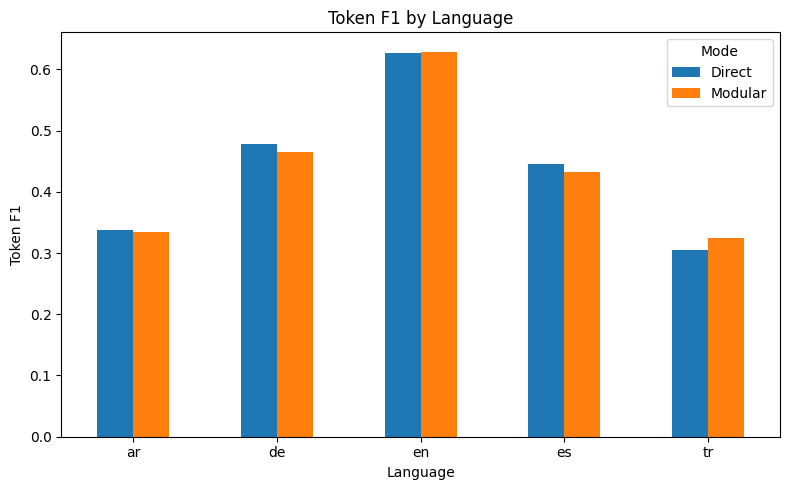

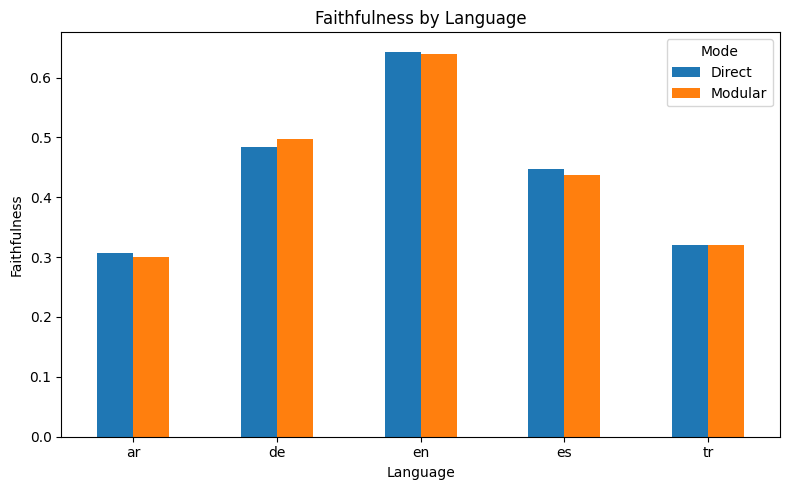

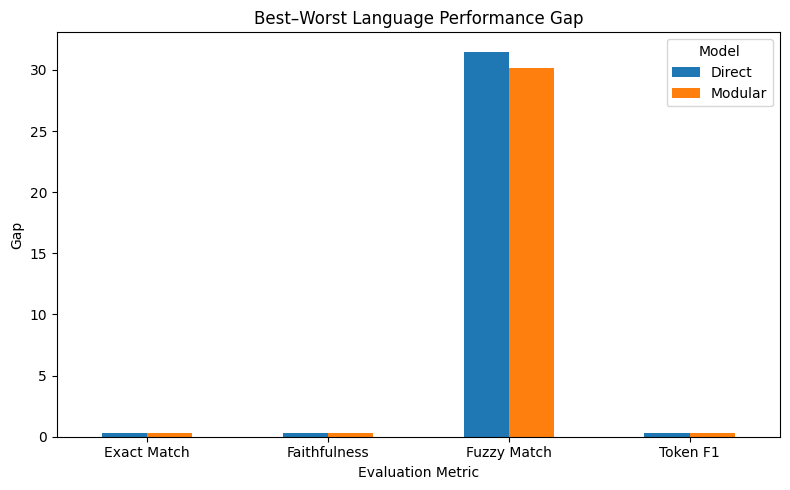

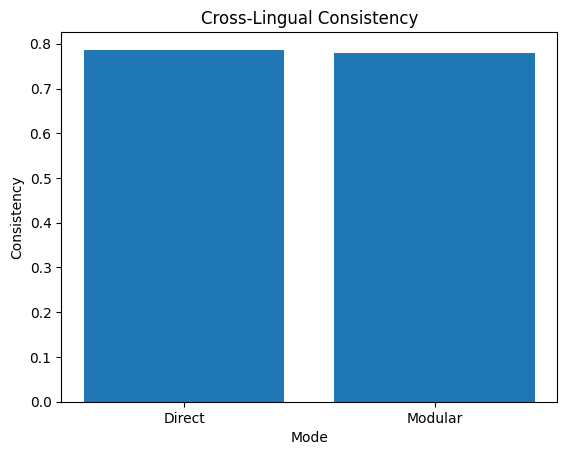

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plot_df = (
    all_results.groupby(["lang", "mode"])["token_f1"]
    .mean()
    .unstack()
)

plot_df.plot(kind="bar", ax=plt.gca())

plt.title("Token F1 by Language")
plt.xlabel("Language")
plt.ylabel("Token F1")
plt.xticks(rotation=0)
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plot_df = (
    all_results.groupby(["lang", "mode"])["faithfulness"]
    .mean()
    .unstack()
)

plot_df.plot(kind="bar", ax=plt.gca())

plt.title("Faithfulness by Language")
plt.xlabel("Language")
plt.ylabel("Faithfulness")
plt.xticks(rotation=0)
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

metrics = {
    "Exact Match": "exact_match",
    "Token F1": "token_f1",
    "Fuzzy Match": "fuzzy_match",
    "Faithfulness": "faithfulness"
}

gap_rows = []

for mode_name, results in [("Direct", direct_df), ("Modular", modular_df)]:

    for metric_name, metric_col in metrics.items():

        lang_scores = results.groupby("lang")[metric_col].mean()

        gap_rows.append({
            "Mode": mode_name,
            "Metric": metric_name,
            "Gap": lang_scores.max() - lang_scores.min(),
            "Best Language": lang_scores.idxmax(),
            "Worst Language": lang_scores.idxmin()
        })

gap_df = pd.DataFrame(gap_rows)

pivot = gap_df.pivot(index="Metric", columns="Mode", values="Gap")

plt.figure(figsize=(8,5))
pivot.plot(kind="bar", ax=plt.gca())

plt.title("Best–Worst Language Performance Gap")
plt.xlabel("Evaluation Metric")
plt.ylabel("Gap")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

gap_df

plt.figure()

cons_df = pd.concat(
    [
        direct_consistency.assign(mode="Direct"),
        modular_consistency.assign(mode="Modular")
    ]
)

plot_cons = cons_df.groupby("mode")["consistency"].mean().reset_index()

plt.bar(plot_cons["mode"], plot_cons["consistency"])
plt.title("Cross-Lingual Consistency")
plt.xlabel("Mode")
plt.ylabel("Consistency")
plt.show()

# 22. Save Outputs

Save the main results as CSV files.


In [ ]:
import shutil

shutil.rmtree('/kaggle/working/results', ignore_errors=True)

In [ ]:
import os

OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

direct_df.to_csv(
    f"{OUTPUT_DIR}/direct_predictions.csv",
    index=False
)

modular_df.to_csv(
    f"{OUTPUT_DIR}/modular_predictions.csv",
    index=False
)

summary_df.to_csv(
    f"{OUTPUT_DIR}/language_summary.csv",
    index=False
)

comparison_df.to_csv(
    f"{OUTPUT_DIR}/mode_comparison.csv"
)

fairness_df.to_csv(
    f"{OUTPUT_DIR}/fairness_metrics.csv",
    index=False
)

consistency_summary.to_csv(
    f"{OUTPUT_DIR}/cross_lingual_consistency.csv",
    index=False
)

gap_df.to_csv(
    f"{OUTPUT_DIR}/language_disparity.csv",
    index=False
)

print(f"All CSV files have been saved to '{OUTPUT_DIR}/'.")


All CSV files have been saved to 'results/'.


# 23. Generate Final Report

The final report should summarize:

- model and dataset,
- direct vs modular performance,
- per-language results,
- interpretability findings,
- language-bias / fairness findings,
- limitations,
- possible extensions.


#### Model and Dataset
In this project: we evaluated the **Qwen2.5-0.5B-Instruct** model on the **XQuAD** multilingual question-answering dataset. The evaluation included English, Arabic, German, Spanish, and Turkish.

# 24. Final Written Analysis

Write your final analysis below.

Your answer should include:

1. A short description of the project.
2. A short explanation of HELM and why holistic evaluation matters.
3. A comparison of direct vs modular results.
4. A discussion of explanation faithfulness.
5. A discussion of multilingual performance.
6. A discussion of language bias and ethical implications.
7. At least three limitations.
8. At least three possible extensions.


## 1.

In this project: we evaluated a multilingual instruction-tuned language model on the XQuAD dataset. We compared a direct question-answering approach with a modular pipeline consisting of a generator, a verifier and a reviser. The goal was to measure answer accuracy, to study faithfulness, multilingual performance and language fairness.

## 2.

In our opinion, HELM provides a much more complete way to evaluate language models(instead of looking only at answer accuracy). It also considers reliability, faithfulness, fairness, and other important aspects. We think this gives a better picture of how trustworthy a model really is!

## 3.

The direct and modular approaches produced very similar results(There is no clear improvement from the modular pipeline). We expected the modular pipeline to improve the answers, but the improvement was quite limited(The difference was so small!). We think the main reason is that the same small model was used for generation, verification, and revision. Because of that the verifier could not provide much new information.

As a result: it seems that the verifier and reviser mostly rephrase rather than correct the outputs!

## 4.

The explanations were sometimes supported by the context(but not always!). In some cases, the selected evidence was not the best sentence (even when the final answer was correct). We think this shows that generating faithful explanations is still a difficult task for small language models(like our case).

## 5. 

The model performed better in English than in the other languages(the gap between English and non-English languages remains significant in all settings)(this is usually reasonable by considering the amount of data that is related to each language in the training phase). German and Spanish also showed reasonable performance. But Arabic and Turkish were more challenging. We also observe that this pattern is stable across both direct and modular systems. In our opinion this suggests that multilingual ability is still uneven across different languages.

## 6.

We think the differences between languages highlight an important fairness issue!!! Users who ask questions in lower-performing languages(Like Turkish compared to English users) may receive less accurate or less reliable answers. This could reduce equal access to AI systems and products like chatbots! That is why multilingual evaluation is an important part of building responsible AI!

## 7.

- Only one relatively small language model was evaluated.
- The generator, verifier, and reviser all used the same model.
- The faithfulness metrics were based on simple heuristics(Actually very simple!!!).
- The evaluation used only a subset of the dataset.
- The experiments focused only on extractive question answering.

## 8.

- Evaluate larger and stronger multilingual language models.
- Use different models for generation and verification(In our opinion, maybe, this is the most important extension for this project).
- Apply stronger semantic methods for evaluating faithfulness.
- Test more languages and multilingual datasets.
- Explore retrieval-augmented or evidence-guided modular pipelines.

## General observations:
- The gap between English and non-English languages remains significant(in all of our settings).
- Evidence selection is often "only partially" aligned with the correct context sentence.
- We think that the main bottleneck in our system is the small model capacity (rather than the evaluation design).
- We also noticed that the system prompts can significantly affect the model’s behavior! Even small changes in wording or structure sometimes lead to noticeable differences in the outputs(We tried that). So this may suggest that part of the performance is sensitive to prompt design!(not only model capability). So some of the observed results may be influenced by prompt engineering choices! Not by the underlying model or pipeline! Actually, we are not sure about it. But it seems reasonable. 

# 25. Suggested Grading Rubric

| Component | Points |
|---|---:|
| Correct dataset loading and preprocessing | 10 |
| Correct HuggingFace model loading | 10 |
| Direct baseline implementation | 10 |
| Modular pipeline implementation | 20 |
| Evaluation metrics | 15 |
| Interpretability / faithfulness analysis | 10 |
| Multilingual fairness and bias/ethics analysis | 15 |
| Plots and saved outputs | 5 |
| Final written discussion | 5 |

Total: 100


**Note:** I noticed that the questions in **Section 5**, **Section 23**, and **Section 24** overlapped. Therefore, I decided to answer them only once instead of repeating the same discussion multiple times! In Section 23, I provided a brief overview of the model and the dataset. Then, in Section 24, I presented the complete discussion and analysis(For answering the 8 suggested questions). I also chose to keep the discussion at a high level rather than jumping into fine-grained details(since the plots and tables already provide the detailed results).

**Note**: I used ChatGPT, GapGPT and DeepSeek to help me understand and complete the tasks. Before starting this assignment, I was not familiar with the pipeline of *Modular Multilingual Trustworthiness Evaluation*. The final code (and analysis) was developed based on my own ideas and my internet searches, with additional help and guidance from these tools. 